<a href="https://colab.research.google.com/github/MehulShukla-git/Movie_Recommendation_System/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Random Forest**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/movies_metadata.csv')

df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

df = df[['title', 'overview', 'genres','tagline','vote_average','popularity']]

df = df.dropna(subset=['title'])

df['overview'] = df['overview'].fillna('')
df['tagline'] = df['tagline'].fillna('')

In [ ]:
import ast

def extract_genres(x):
    try:
        return " ".join([i['name'] for i in ast.literal_eval(x)])
    except:
        return ""

df['genres'] = df['genres'].apply(extract_genres)

In [ ]:
df['tags'] = df['overview'] + " " + df['genres'] + " " + df['tagline']

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df['tags'] = df['tags'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['tags'])

# Convert numeric
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce').fillna(0)
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce').fillna(0)

X_num = df[['vote_average','popularity']].values

# Combine
X = hstack((tfidf_matrix, X_num)).tocsr()

In [ ]:
df['target'] = df['vote_average'].apply(lambda x: 1 if x >= 6 else 0)

y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_dense = X.toarray()

X_train, X_test, y_train, y_test = train_test_split(
    X_dense, y, test_size=0.2, random_state=42
)

RANDOM FOREST MODEL

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== RANDOM FOREST ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

=== RANDOM FOREST ===
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


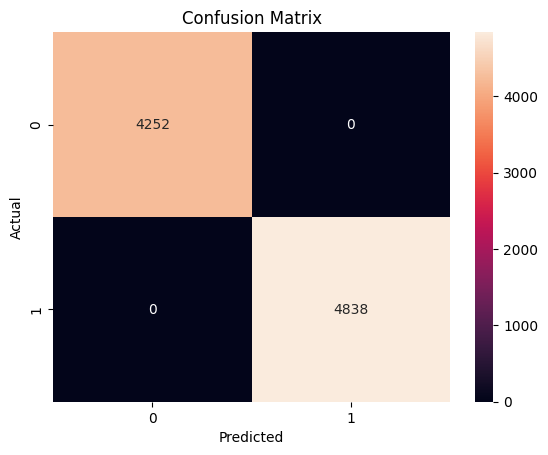

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

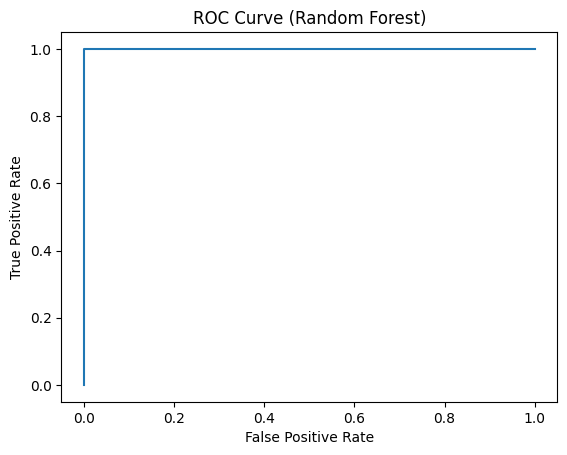

ROC-AUC Score: 1.0


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest)")
plt.show()

print("ROC-AUC Score:", auc)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4252
           1       1.00      1.00      1.00      4838

    accuracy                           1.00      9090
   macro avg       1.00      1.00      1.00      9090
weighted avg       1.00      1.00      1.00      9090



In [ ]:
import numpy as np

importances = rf.feature_importances_

indices_imp = np.argsort(importances)[-20:]

plt.figure()
plt.barh(range(len(indices_imp)), importances[indices_imp])
plt.yticks(range(len(indices_imp)), indices_imp)
plt.title("Top Feature Importance")
plt.show()

In [ ]:
df['title'] = df['title'].str.lower()
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

def recommend_rf(movie_name, top_n=10):
    movie_name = movie_name.lower()

    if movie_name not in indices:
        return "Movie not found"

    # Predict probability for all movies
    probs = rf.predict_proba(X_dense)[:,1]

    df['score'] = probs

    recs = df[df['title'] != movie_name]

    recs = recs.sort_values(by=['score','popularity'], ascending=False)

    recommendations = recs['title'].head(top_n).values

    print(f"\nInput Movie: {movie_name}")
    print("\nRecommended Movies:\n")

    for i, movie in enumerate(recommendations, 1):
        print(f"{i}. {movie}")

In [ ]:
movie = input("Enter movie name: ").lower()
recommend_rf(movie)